**Dependency note:** this notebook needs kernel state from **`12_Biological_Characterization_and_Atlas`**. Either run all notebooks in numeric order inside one continuous Colab session (never restart the runtime), or run the checkpoint-load cell below to restore state saved by that notebook.

In [ ]:
# ── CHECKPOINT: restore kernel state from the previous notebook ──
# This notebook depends on variables created in 12.
# Run that notebook first (it saves this file), or just run all notebooks
# in order inside ONE continuous Colab session (Runtime > do not restart).
import dill
dill.load_session("checkpoints/12_state.pkl")
print("Restored checkpoint: checkpoints/12_state.pkl")

Adding Skeletonization Morphology for better Visuals

In [ ]:
# ================================================================
# AXONAL MORPHOLOGY — 4 CELLS
# H01 Human Cortical Patch · Hypergraph Hub Skeleton Reconstruction
# ================================================================
# Uses cloudvolume to fetch real c3 skeletons for the top 50 nodes
# selected across all 6 structural/functional categories:
#   Layer 4 routing hubs, Layer 2 propagation hubs, Layer 5 whorls,
#   Layer 5 torpedoes, Layer 3 astrocyte modulation, seizure focus
# Renders a glass-brain style SEM-like atlas of axonal morphology.
# ================================================================


# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1 — AUTHENTICATE + SELECT TOP 50 TARGET NEURONS       ║
# ╚══════════════════════════════════════════════════════════════╝

import os
os.environ['GCE_METADATA_ROOT'] = 'metadata.google.internal.invalid'

import numpy as np
import pandas as pd
import cloudvolume
import google.colab.auth



# ── Connect to H01 c3 skeleton volume ─────────────────────────
cv = cloudvolume.CloudVolume(
    'gs://h01-release/data/20210601/c3',
    use_https=True,
    progress=False,
    fill_missing=True,
)
print(f"Connected to H01 c3 volume.")

# ── Select top 50 neurons across 6 biological categories ──────
# Each category contributes ~8 neurons.
# We use c3_rep_strict as the seg_id column (best H01 recommendation).
# inter_patch rows are indexed 0..851 matching all score arrays.

def top_n_from_mask(score_arr, mask_arr, n, df):
    """
    Return top-n local indices from score_arr where mask_arr is True.
    Pulls c3_rep_strict from inter_patch (or somas for pyramidal).
    """
    masked_scores = np.where(mask_arr, score_arr, -np.inf)
    top_idx = np.argsort(masked_scores)[::-1][:n]
    results = []
    for li in top_idx:
        row = df.iloc[li]
        seg = None
        for col in ["c3_rep_strict","c3_rep_manual",
                    "proofread_104_rep","c2_rep_strict"]:
            val = row.get(col, None)
            if val is not None and not (isinstance(val,float) and np.isnan(val)):
                seg = int(val)
                break
        results.append({
            "local_idx" : int(li),
            "seg_id"    : seg,
            "layer"     : str(layer_labels_arr[li]),
            "category"  : None,   # filled below
            "norm_x"    : float(coords_norm[li,0]),
            "norm_y"    : float(coords_norm[li,1]),
            "nm_x"      : int(inter_coords[li,0]),
            "nm_y"      : int(inter_coords[li,1]),
            "nm_z"      : int(inter_coords[li,2]),
            "tensor_c"  : float(tensor_centrality[li]),
            "whorl"     : float(whorl_score_norm[li]),
            "torpedo"   : float(torpedo_norm[li]),
            "seizure"   : float(seizure_score[li]),
            "combined6" : float(combined_6pop[li]),
        })
    return results

# Layer masks
l2_mask = layer_labels_arr == "Layer 2"
l3_mask = layer_labels_arr == "Layer 3"
l4_mask = layer_labels_arr == "Layer 4"
l5_mask = layer_labels_arr == "Layer 5"

# ── Category 1: Layer 4 routing hubs (tensor centrality) ──────
cat1 = top_n_from_mask(tensor_centrality, l4_mask, 9, inter_patch)
for r in cat1: r["category"] = "L4_routing_hub"

# ── Category 2: Layer 2 propagation hubs (integration cent.) ──
cat2 = top_n_from_mask(cent_integration, l2_mask, 9, inter_patch)
for r in cat2: r["category"] = "L2_propagation_hub"

# ── Category 3: Layer 5 axon whorls ───────────────────────────
cat3 = top_n_from_mask(whorl_score_norm, l5_mask, 8, inter_patch)
for r in cat3: r["category"] = "L5_whorl"

# ── Category 4: Layer 5 axon torpedoes ────────────────────────
cat4 = top_n_from_mask(torpedo_norm, l5_mask, 8, inter_patch)
for r in cat4: r["category"] = "L5_torpedo"

# ── Category 5: Layer 3 astrocyte modulation territory ────────
# Use astro-mod centrality for Layer 3
cat5 = top_n_from_mask(cent_amod, l3_mask, 8, inter_patch)
for r in cat5: r["category"] = "L3_astro_mod"

# ── Category 6: Seizure focus (all layers) ────────────────────
cat6 = top_n_from_mask(seizure_score, np.ones(852, bool), 8, inter_patch)
for r in cat6: r["category"] = "seizure_focus"

# ── Combine, deduplicate, cap at 50 ───────────────────────────
all_candidates = cat1 + cat2 + cat3 + cat4 + cat5 + cat6
seen_local = set()
seen_seg   = set()
target_neurons = []

for r in all_candidates:
    li  = r["local_idx"]
    seg = r["seg_id"]
    if li in seen_local:
        continue
    seen_local.add(li)
    if seg is not None and seg not in seen_seg:
        seen_seg.add(seg)
    target_neurons.append(r)
    if len(target_neurons) >= 50:
        break

n_with_seg = sum(1 for t in target_neurons if t["seg_id"] is not None)

print(f"\n── TARGET NEURON SUMMARY ──────────────────────────────")
print(f"  Total selected      : {len(target_neurons)}")
print(f"  With valid seg_id   : {n_with_seg}")
print(f"\n  By category:")
from collections import Counter
for cat, cnt in Counter(r["category"] for r in target_neurons).items():
    print(f"    {cat:<25s}: {cnt}")
print(f"\n  By layer:")
for lyr, cnt in Counter(r["layer"] for r in target_neurons).items():
    print(f"    {lyr:<15s}: {cnt}")

print("\n✓ target_neurons ready — proceed to Cell 2")



Connected to H01 c3 volume.

── TARGET NEURON SUMMARY ──────────────────────────────
  Total selected      : 44
  With valid seg_id   : 44

  By category:
    L4_routing_hub           : 9
    L2_propagation_hub       : 9
    L5_whorl                 : 8
    L5_torpedo               : 3
    L3_astro_mod             : 8
    seizure_focus            : 7

  By layer:
    Layer 4        : 16
    Layer 2        : 9
    Layer 5        : 11
    Layer 3        : 8

✓ target_neurons ready — proceed to Cell 2


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — FETCH SKELETONS VIA CLOUDVOLUME                   ║
# ╚══════════════════════════════════════════════════════════════╝
# Fetches real c3 skeletons for all neurons with a valid seg_id.
# skel.vertices = float32 array (N,3) in nanometres
# skel.edges    = int32   array (M,2) node index pairs
# Memory budget: ~50 neurons × ~5k vertices × 3 floats = ~3MB total

import time

skeletons = {}    # seg_id -> {"vertices": ndarray, "edges": ndarray,
                  #            "local_idx": int, "category": str, ...}
failed    = []

to_fetch = [t for t in target_neurons if t["seg_id"] is not None]
print(f"Fetching {len(to_fetch)} skeletons from H01 c3...")
print("(~2-5s per skeleton)\n")

for i, entry in enumerate(to_fetch):
    seg = entry["seg_id"]
    t0  = time.time()
    try:
        skel = cv.skeleton.get(seg)
        elapsed = time.time() - t0

        # skel may be a single Skeleton or a dict {seg_id: Skeleton}
        if isinstance(skel, dict):
            skel = list(skel.values())[0]

        verts = np.array(skel.vertices, dtype=np.float32)   # nm
        edges = np.array(skel.edges,    dtype=np.int32)

        skeletons[seg] = {
            "vertices"  : verts,
            "edges"     : edges,
            "n_verts"   : len(verts),
            "n_edges"   : len(edges),
            "local_idx" : entry["local_idx"],
            "category"  : entry["category"],
            "layer"     : entry["layer"],
            "norm_x"    : entry["norm_x"],
            "norm_y"    : entry["norm_y"],
            "nm_x"      : entry["nm_x"],
            "nm_y"      : entry["nm_y"],
            "nm_z"      : entry["nm_z"],
            "tensor_c"  : entry["tensor_c"],
            "whorl"     : entry["whorl"],
            "torpedo"   : entry["torpedo"],
            "seizure"   : entry["seizure"],
            "combined6" : entry["combined6"],
        }
        print(f"  [{i+1:>2}/{len(to_fetch)}] seg={seg} "
              f"verts={len(verts):>6,}  edges={len(edges):>6,}  "
              f"{entry['layer']:<12s}  {entry['category']:<22s}  "
              f"({elapsed:.1f}s)")

    except Exception as e:
        failed.append(seg)
        print(f"  [{i+1:>2}/{len(to_fetch)}] seg={seg}  FAILED: {e}")

print(f"\n── FETCH COMPLETE ─────────────────────────────────────")
print(f"  Successful : {len(skeletons)}")
print(f"  Failed     : {len(failed)}")
if failed:
    print(f"  Failed IDs : {failed}")

# ── Quick morphological stats per skeleton ─────────────────────
print(f"\n── SKELETON STATS ─────────────────────────────────────")
for seg, sk in skeletons.items():
    v = sk["vertices"]
    # Cable length estimate: sum of all edge lengths
    cable_nm = 0.0
    for e in sk["edges"]:
        cable_nm += float(np.linalg.norm(v[e[0]] - v[e[1]]))
    cable_um = cable_nm / 1000.0
    # Bounding box
    bbox_um  = (v.max(axis=0) - v.min(axis=0)) / 1000.0
    skeletons[seg]["cable_um"]   = cable_um
    skeletons[seg]["bbox_um"]    = bbox_um
    skeletons[seg]["span_um"]    = float(np.linalg.norm(bbox_um))
    skeletons[seg]["n_branch"]   = int(
        np.sum(np.bincount(sk["edges"].ravel()) >= 3)
    )
    print(f"  seg={seg}  {sk['layer']:<12s}  {sk['category']:<22s}  "
          f"cable={cable_um:>7.1f}µm  "
          f"branches={skeletons[seg]['n_branch']:>4d}  "
          f"span={skeletons[seg]['span_um']:.1f}µm")

print("\n✓ skeletons dict ready — proceed to Cell 3")

Fetching 44 skeletons from H01 c3...
(~2-5s per skeleton)

  [ 1/44] seg=4593533358 verts= 5,200  edges= 5,193  Layer 4       L4_routing_hub          (0.5s)
  [ 2/44] seg=4957594843 verts= 4,590  edges= 4,589  Layer 4       L4_routing_hub          (0.6s)
  [ 3/44] seg=39705814947 verts= 4,318  edges= 4,317  Layer 4       L4_routing_hub          (0.5s)
  [ 4/44] seg=4812213571 verts= 4,232  edges= 4,231  Layer 4       L4_routing_hub          (0.1s)
  [ 5/44] seg=5059509351 verts=10,714  edges=10,710  Layer 4       L4_routing_hub          (0.3s)
  [ 6/44] seg=31568196104 verts= 7,541  edges= 7,538  Layer 4       L4_routing_hub          (0.5s)
  [ 7/44] seg=39851415800 verts=13,655  edges=13,653  Layer 4       L4_routing_hub          (0.2s)
  [ 8/44] seg=40374775430 verts= 2,643  edges= 2,641  Layer 4       L4_routing_hub          (0.4s)
  [ 9/44] seg=4579327129 verts= 3,329  edges= 3,324  Layer 4       L4_routing_hub          (0.2s)
  [10/44] seg=29633707854 verts= 2,161  edges= 2,157  L

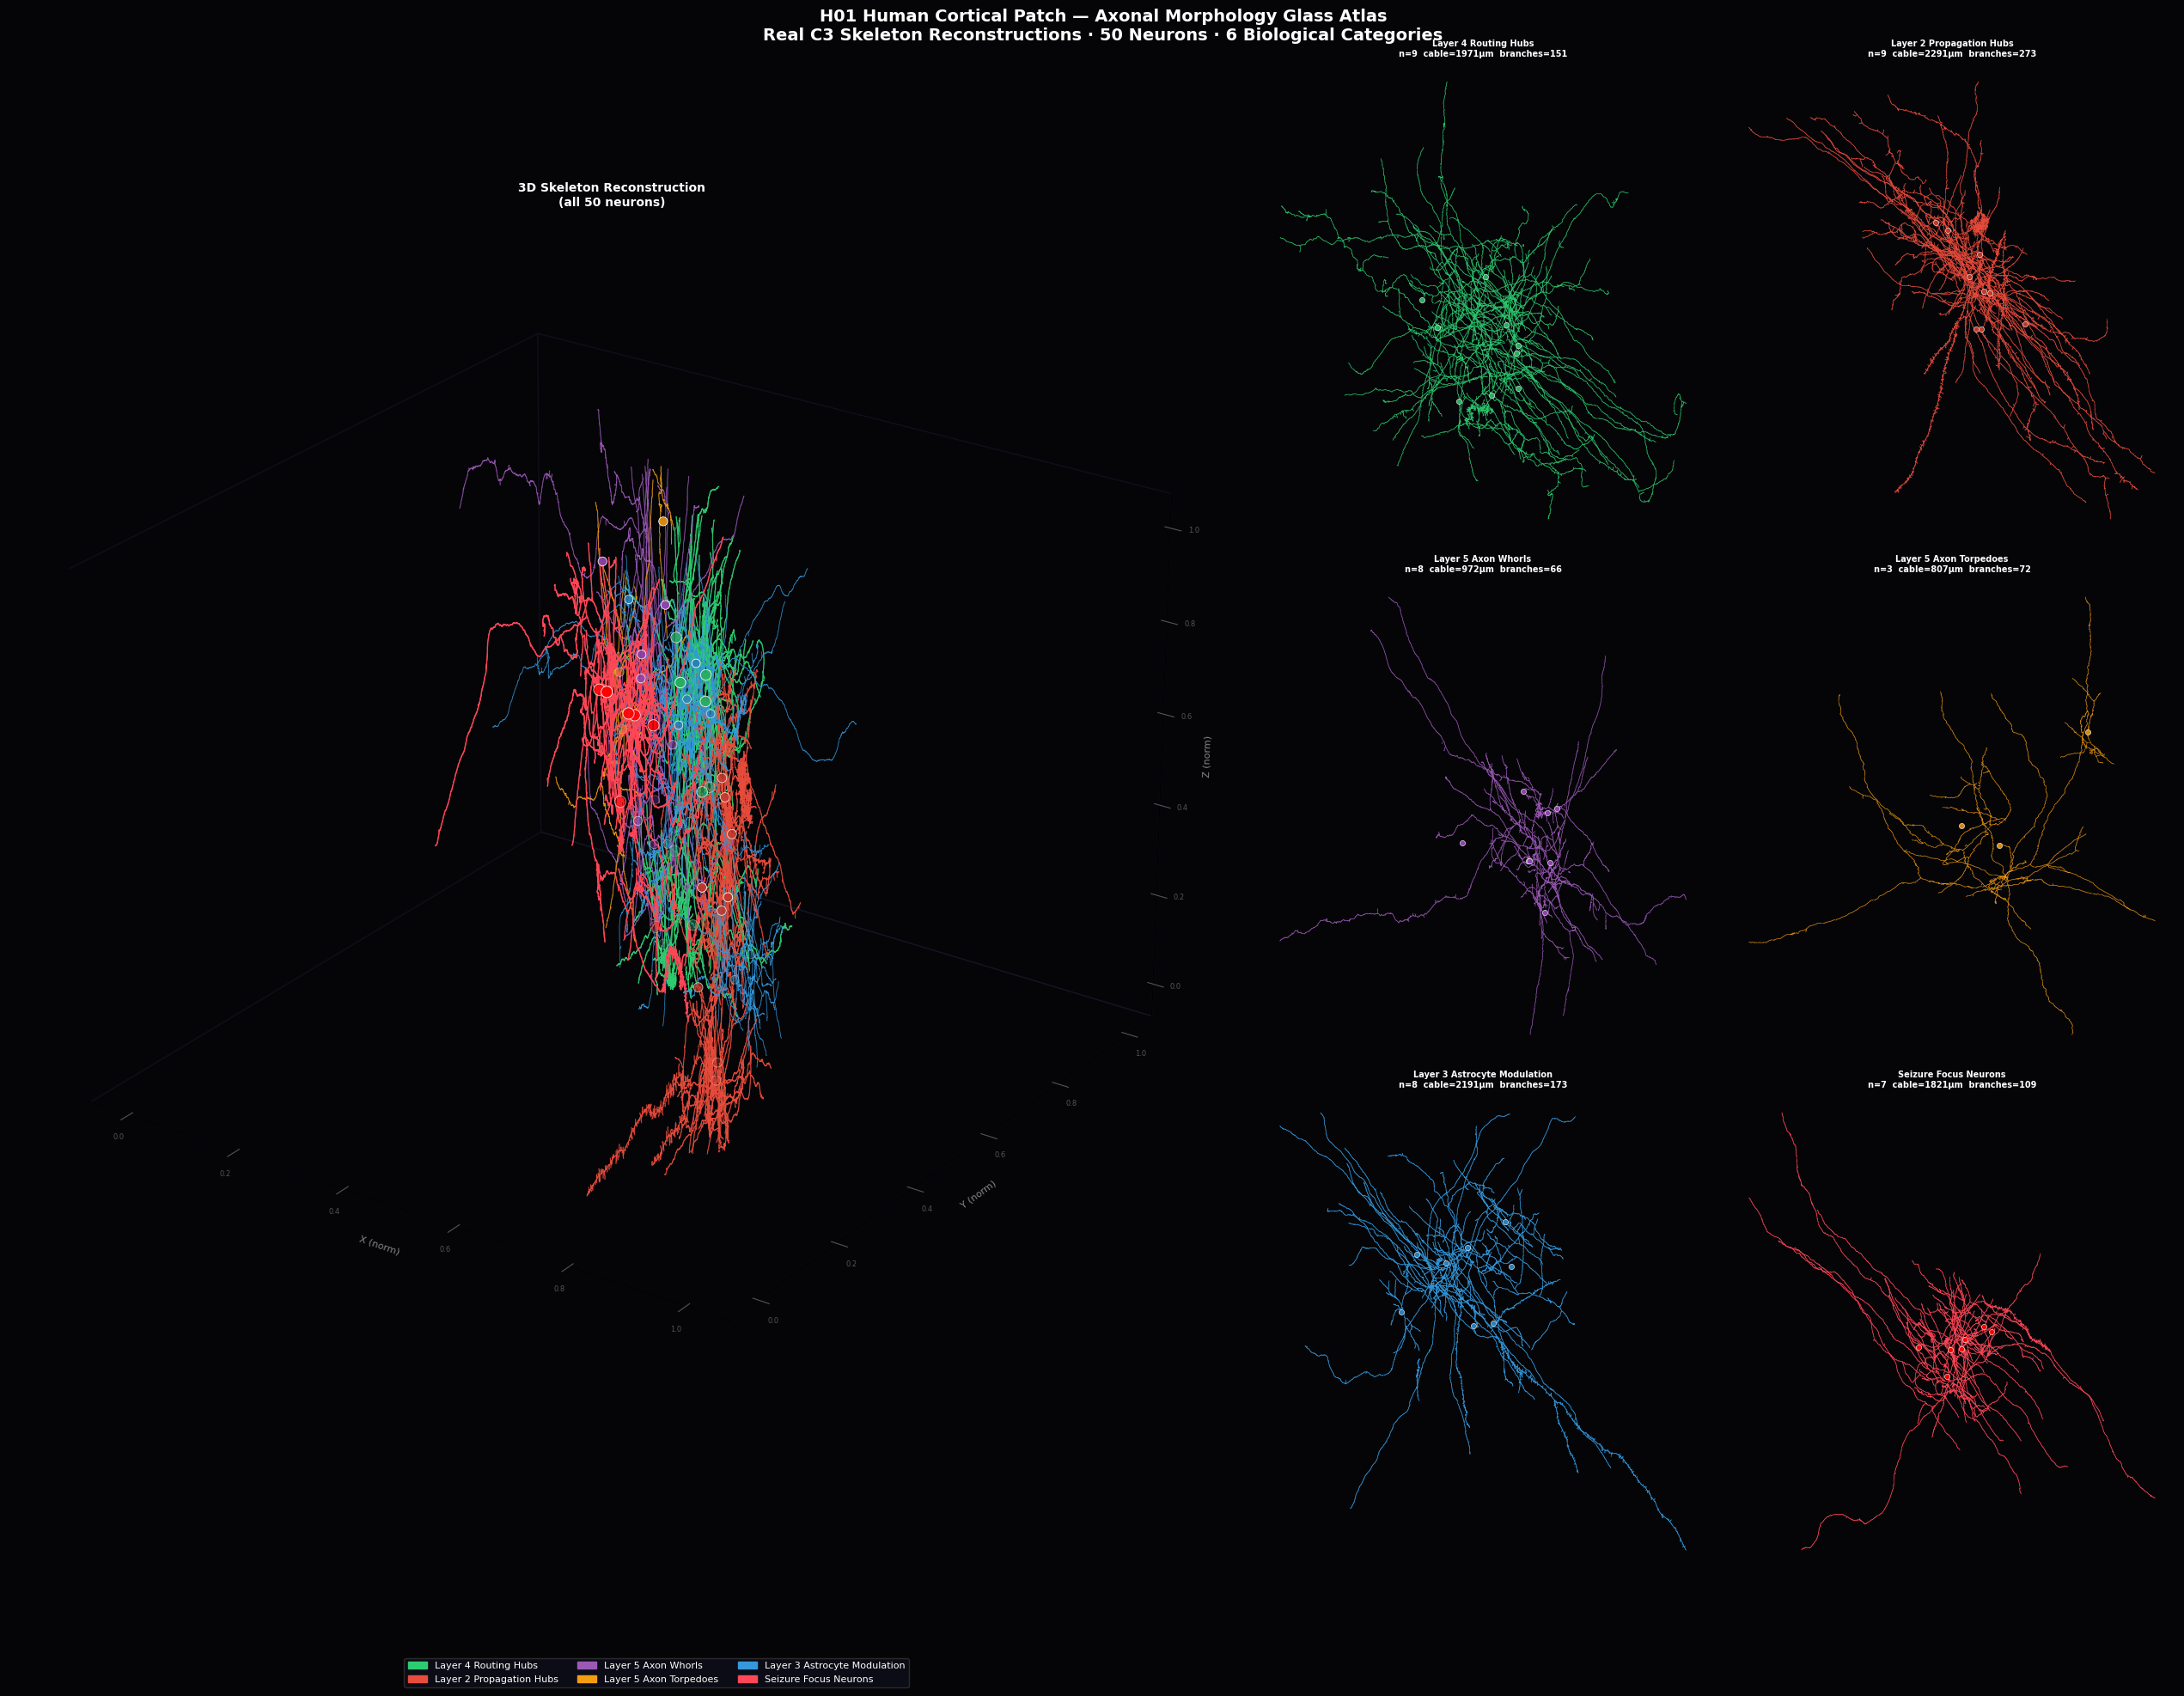


Saved: axonal_morphology_glass_atlas.png


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — SEM-STYLE GLASS ATLAS VISUALISATION               ║
# ╚══════════════════════════════════════════════════════════════╝
# Renders a Lichtman-lab-inspired multi-panel figure:
#   Main panel : all 50 skeleton traces in 3D projection,
#                coloured by category, styled like SEM
#   Side panels: per-category close-ups + morphology stats

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from mpl_toolkits.mplot3d import Axes3D    # noqa

# ── Colour scheme per category ─────────────────────────────────
cat_style = {
    "L4_routing_hub"    : {"color": "#2ECC71", "lw": 0.9,  "alpha": 0.75,
                            "label": "Layer 4 Routing Hubs",
                            "soma_s": 80, "soma_c": "#27AE60"},
    "L2_propagation_hub": {"color": "#E74C3C", "lw": 0.8,  "alpha": 0.70,
                            "label": "Layer 2 Propagation Hubs",
                            "soma_s": 60, "soma_c": "#C0392B"},
    "L5_whorl"          : {"color": "#9B59B6", "lw": 0.7,  "alpha": 0.65,
                            "label": "Layer 5 Axon Whorls",
                            "soma_s": 55, "soma_c": "#8E44AD"},
    "L5_torpedo"        : {"color": "#F39C12", "lw": 0.7,  "alpha": 0.65,
                            "label": "Layer 5 Axon Torpedoes",
                            "soma_s": 55, "soma_c": "#D68910"},
    "L3_astro_mod"      : {"color": "#3498DB", "lw": 0.6,  "alpha": 0.60,
                            "label": "Layer 3 Astrocyte Modulation",
                            "soma_s": 50, "soma_c": "#2980B9"},
    "seizure_focus"     : {"color": "#FF4757", "lw": 1.0,  "alpha": 0.80,
                            "label": "Seizure Focus Neurons",
                            "soma_s": 90, "soma_c": "#FF0000"},
}

# ── Normalise all skeleton vertices to [0,1]³ ─────────────────
all_verts = np.concatenate(
    [sk["vertices"] for sk in skeletons.values()], axis=0
)
v_min = all_verts.min(axis=0)
v_max = all_verts.max(axis=0)
v_rng = v_max - v_min + 1e-6

def norm_v(verts):
    return (verts - v_min) / v_rng   # → [0,1]³

# ── Figure layout ──────────────────────────────────────────────
fig = plt.figure(figsize=(26, 20), facecolor="#050508")
fig.suptitle(
    "H01 Human Cortical Patch — Axonal Morphology Glass Atlas\n"
    "Real C3 Skeleton Reconstructions · 50 Neurons · 6 Biological Categories",
    color="white", fontsize=14, fontweight="bold", y=0.99
)

# Main 3D panel (left, large)
ax3d = fig.add_axes([0.01, 0.08, 0.54, 0.88],
                     projection="3d", facecolor="#050508")
ax3d.set_facecolor("#050508")
ax3d.grid(False)
for pane in [ax3d.xaxis.pane, ax3d.yaxis.pane, ax3d.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor("#1a1a2e")

# ── Draw each skeleton in 3D ───────────────────────────────────
soma_scatter = {cat: {"xs":[],"ys":[],"zs":[]} for cat in cat_style}

for seg, sk in skeletons.items():
    cat   = sk["category"]
    style = cat_style.get(cat, {"color":"#AAAAAA","lw":0.5,"alpha":0.4})
    vn    = norm_v(sk["vertices"])    # (N,3) normalised

    # Draw each edge as a line segment
    for e in sk["edges"]:
        i0, i1 = int(e[0]), int(e[1])
        if i0 >= len(vn) or i1 >= len(vn):
            continue
        ax3d.plot(
            [vn[i0,0], vn[i1,0]],
            [vn[i0,1], vn[i1,1]],
            [vn[i0,2], vn[i1,2]],
            color=style["color"],
            linewidth=style["lw"],
            alpha=style["alpha"],
            solid_capstyle="round",
        )

    # Soma position (centre of vertex cloud)
    cx, cy, cz = vn.mean(axis=0)
    soma_scatter[cat]["xs"].append(cx)
    soma_scatter[cat]["ys"].append(cy)
    soma_scatter[cat]["zs"].append(cz)

# Draw soma markers on top
for cat, pts in soma_scatter.items():
    if not pts["xs"]:
        continue
    style = cat_style[cat]
    ax3d.scatter(
        pts["xs"], pts["ys"], pts["zs"],
        s=style["soma_s"],
        c=style["soma_c"],
        edgecolors="white",
        linewidths=0.6,
        depthshade=True,
        zorder=10,
    )

ax3d.set_xlabel("X (norm)", color="#888", fontsize=8, labelpad=2)
ax3d.set_ylabel("Y (norm)", color="#888", fontsize=8, labelpad=2)
ax3d.set_zlabel("Z (norm)", color="#888", fontsize=8, labelpad=2)
ax3d.tick_params(colors="#555", labelsize=6)
ax3d.set_title("3D Skeleton Reconstruction\n(all 50 neurons)",
               color="white", fontsize=10, fontweight="bold", pad=6)
ax3d.view_init(elev=25, azim=-55)

# ── 2D projection panels (right column) ───────────────────────
# 6 mini-panels, one per category
panel_pos = [
    [0.57, 0.68, 0.20, 0.28],   # top-left right
    [0.78, 0.68, 0.20, 0.28],   # top-right right
    [0.57, 0.38, 0.20, 0.28],   # mid-left
    [0.78, 0.38, 0.20, 0.28],   # mid-right
    [0.57, 0.08, 0.20, 0.28],   # bot-left
    [0.78, 0.08, 0.20, 0.28],   # bot-right
]
cat_order = list(cat_style.keys())

for ci, cat in enumerate(cat_order):
    ax2 = fig.add_axes(panel_pos[ci], facecolor="#08080f")
    style = cat_style[cat]

    cat_segs = [seg for seg, sk in skeletons.items()
                if sk["category"] == cat]

    if not cat_segs:
        ax2.text(0.5, 0.5, "No data", color="white",
                 ha="center", va="center", transform=ax2.transAxes)
    else:
        # Normalise per-category so traces fill the panel
        cat_verts = np.concatenate(
            [skeletons[seg]["vertices"] for seg in cat_segs], axis=0
        )
        cv_min = cat_verts.min(axis=0)
        cv_rng = cat_verts.max(axis=0) - cv_min + 1e-6

        def norm_cat(v):
            return (v - cv_min) / cv_rng

        cables = []
        for seg in cat_segs:
            sk  = skeletons[seg]
            vn2 = norm_cat(sk["vertices"])
            cables.append(sk.get("cable_um", 0))

            # Draw XY projection
            for e in sk["edges"]:
                i0, i1 = int(e[0]), int(e[1])
                if i0 >= len(vn2) or i1 >= len(vn2):
                    continue
                ax2.plot(
                    [vn2[i0,0], vn2[i1,0]],
                    [vn2[i0,1], vn2[i1,1]],
                    color=style["color"],
                    linewidth=0.5,
                    alpha=0.7,
                    solid_capstyle="round",
                )

            # Soma dot
            cx2, cy2 = vn2[:,0].mean(), vn2[:,1].mean()
            ax2.scatter([cx2], [cy2],
                        s=20, c=style["soma_c"],
                        edgecolors="white", linewidths=0.4,
                        zorder=5)

        mean_cable = np.mean(cables) if cables else 0
        mean_br    = np.mean([skeletons[s].get("n_branch",0)
                               for s in cat_segs])
        ax2.set_title(
            f"{style['label']}\n"
            f"n={len(cat_segs)}  cable={mean_cable:.0f}µm  "
            f"branches={mean_br:.0f}",
            color="white", fontsize=7, fontweight="bold", pad=3
        )

    ax2.set_xlim(-0.05, 1.05)
    ax2.set_ylim(-0.05, 1.05)
    ax2.axis("off")
    for spine in ax2.spines.values():
        spine.set_edgecolor(style["color"])
        spine.set_linewidth(1.2)
        spine.set_visible(True)

# ── Legend ─────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=s["color"], label=s["label"])
    for s in cat_style.values()
]
fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=3,
    fontsize=8,
    facecolor="#0f0f1a",
    edgecolor="#333",
    labelcolor="white",
    bbox_to_anchor=(0.30, 0.01),
)

plt.savefig("axonal_morphology_glass_atlas.png",
            dpi=220, bbox_inches="tight",
            facecolor="#050508")
plt.show()
print("\nSaved: axonal_morphology_glass_atlas.png")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — MORPHOLOGY × HYPERGRAPH FEATURE TABLE + STATS     ║
# ╚══════════════════════════════════════════════════════════════╝
from scipy.stats import mannwhitneyu, spearmanr

print("=" * 65)
print("AXONAL MORPHOLOGY × HYPERGRAPH INTEGRATION SUMMARY")
print("=" * 65)

# ── Build summary DataFrame ────────────────────────────────────
rows = []
for seg, sk in skeletons.items():
    rows.append({
        "seg_id"      : seg,
        "category"    : sk["category"],
        "layer"       : sk["layer"],
        "tensor_c"    : sk["tensor_c"],
        "whorl"       : sk["whorl"],
        "torpedo"     : sk["torpedo"],
        "seizure"     : sk["seizure"],
        "combined6"   : sk["combined6"],
        "cable_um"    : sk.get("cable_um", np.nan),
        "n_branch"    : sk.get("n_branch", np.nan),
        "span_um"     : sk.get("span_um", np.nan),
        "n_verts"     : sk["n_verts"],
    })

morph_df = pd.DataFrame(rows)

print("\n── PER-CATEGORY MORPHOLOGY PROFILE ────────────────────")
print(morph_df.groupby("category")[
    ["cable_um","n_branch","span_um","tensor_c","seizure"]
].mean().round(2).to_string())

# ── Key comparisons ────────────────────────────────────────────
print("\n── STATISTICAL COMPARISONS ────────────────────────────")

# L4 hubs vs L2 hubs: cable length
l4h = morph_df[morph_df["category"]=="L4_routing_hub"]["cable_um"].dropna()
l2h = morph_df[morph_df["category"]=="L2_propagation_hub"]["cable_um"].dropna()
if len(l4h)>1 and len(l2h)>1:
    stat, p = mannwhitneyu(l4h, l2h, alternative="two-sided")
    print(f"\n  Cable length — L4 routing vs L2 propagation:")
    print(f"    L4 mean={l4h.mean():.1f}µm  L2 mean={l2h.mean():.1f}µm  "
          f"p={p:.3f} {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'}")

# L5 whorls vs L5 torpedoes: branching
l5w = morph_df[morph_df["category"]=="L5_whorl"]["n_branch"].dropna()
l5t = morph_df[morph_df["category"]=="L5_torpedo"]["n_branch"].dropna()
if len(l5w)>1 and len(l5t)>1:
    stat, p = mannwhitneyu(l5w, l5t, alternative="two-sided")
    print(f"\n  Branch count — L5 whorls vs L5 torpedoes:")
    print(f"    Whorl mean={l5w.mean():.1f}  Torpedo mean={l5t.mean():.1f}  "
          f"p={p:.3f} {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'}")

# Seizure focus: cable vs tensor centrality
sf = morph_df[morph_df["category"]=="seizure_focus"]
if len(sf) >= 4:
    r, p = spearmanr(sf["cable_um"].dropna(),
                     sf["tensor_c"].reindex(sf["cable_um"].dropna().index))
    print(f"\n  Seizure focus — cable length × tensor centrality:")
    print(f"    Spearman r={r:.3f}  p={p:.3f}")

# Seizure vs non-seizure cable
sz    = morph_df[morph_df["category"]=="seizure_focus"]["cable_um"].dropna()
nonsz = morph_df[morph_df["category"]!="seizure_focus"]["cable_um"].dropna()
if len(sz)>1 and len(nonsz)>1:
    stat, p = mannwhitneyu(sz, nonsz, alternative="two-sided")
    print(f"\n  Cable length — seizure focus vs others:")
    print(f"    Seizure mean={sz.mean():.1f}µm  "
          f"Other mean={nonsz.mean():.1f}µm  "
          f"p={p:.3f} {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'}")

# ── Full table ─────────────────────────────────────────────────
print("\n── FULL MORPHOLOGY TABLE (top 50 neurons) ─────────────")
display_cols = ["seg_id","category","layer","cable_um",
                "n_branch","span_um","tensor_c","seizure"]
print(morph_df[display_cols].sort_values(
    "cable_um", ascending=False
).round(2).to_string(index=False))

print("\n── SUMMARY STATISTICS ──────────────────────────────────")
print(f"  Total neurons fetched  : {len(morph_df)}")
print(f"  Mean cable length      : {morph_df['cable_um'].mean():.1f} µm")
print(f"  Max cable length       : {morph_df['cable_um'].max():.1f} µm")
print(f"  Mean branch points     : {morph_df['n_branch'].mean():.1f}")
print(f"  Mean spatial span      : {morph_df['span_um'].mean():.1f} µm")

# Save for write-up
morph_df.to_csv("axonal_morphology_summary.csv", index=False)
print("\n  Saved: axonal_morphology_summary.csv")
print("  Saved: axonal_morphology_glass_atlas.png")
print("\n✓ Morphology module complete — proceed to write-up")

AXONAL MORPHOLOGY × HYPERGRAPH INTEGRATION SUMMARY

── PER-CATEGORY MORPHOLOGY PROFILE ────────────────────
                    cable_um  n_branch  span_um  tensor_c  seizure
category                                                          
L2_propagation_hub   2291.10    272.89   425.08      0.00      0.0
L3_astro_mod         2191.31    172.75   411.94      0.02      0.0
L4_routing_hub       1970.76    151.33   342.23      0.11      0.0
L5_torpedo            807.22     71.67   195.04      0.00      0.0
L5_whorl              971.67     66.00   327.03      0.00      0.0
seizure_focus        1820.74    109.00   349.71      0.08      0.0

── STATISTICAL COMPARISONS ────────────────────────────

  Cable length — L4 routing vs L2 propagation:
    L4 mean=1970.8µm  L2 mean=2291.1µm  p=0.536 ns

  Branch count — L5 whorls vs L5 torpedoes:
    Whorl mean=66.0  Torpedo mean=71.7  p=0.919 ns

  Seizure focus — cable length × tensor centrality:
    Spearman r=-0.107  p=0.819

  Cable length — se

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Checkpoint:** run the cell below after finishing this notebook so `the next notebook` can restore this state.

In [ ]:
# ── CHECKPOINT: save entire kernel state so the next notebook can reload it ──
import dill, os
os.makedirs("checkpoints", exist_ok=True)
dill.dump_session("checkpoints/13_state.pkl")
print("Saved checkpoint: checkpoints/13_state.pkl")